In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
BASE = '/content/drive/MyDrive/Violence_detector_v2'
os.makedirs(BASE, exist_ok=True)
print('✅ Drive mounted. Working folder:', BASE)

Mounted at /content/drive
✅ Drive mounted. Working folder: /content/drive/MyDrive/Violence_detector_v2


In [2]:
!pip install -q kaggle librosa soundfile tqdm scikit-learn

import os, random, json
import numpy as np
import librosa
import soundfile as sf
import joblib
from tqdm.notebook import tqdm
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
)
import matplotlib.pyplot as plt
print('✅ All imports done')

✅ All imports done


In [4]:
import os
import json

# Paste your Kaggle username and the token you just generated
kaggle_creds = {
    "username": "shubhampenkar",   # replace this
    "key": "KGAT_9e29ee1740072a0dba0e187b71d65854"            # paste new token here (regenerate first!)
}

os.makedirs('/root/.config/kaggle', exist_ok=True)
with open('/root/.config/kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_creds, f)
os.chmod('/root/.config/kaggle/kaggle.json', 0o600)
print('✅ Kaggle credentials set')

✅ Kaggle credentials set


In [5]:
# ── Download RAVDESS (215MB) and CREMA-D (~900MB) ─────────────────────────────
# RAVDESS: 1440 individually labelled speech clips, 24 actors
# CREMA-D: 7442 clips, 91 diverse actors, crowd-sourced labels

DATA_DIR = '/content/datasets'
os.makedirs(DATA_DIR, exist_ok=True)

print('📥 Downloading RAVDESS...')
!kaggle datasets download -d uwrfkaggler/ravdess-emotional-speech-audio -p {DATA_DIR} --unzip -q
print('✅ RAVDESS downloaded')

print('📥 Downloading CREMA-D...')
!kaggle datasets download -d ejlok1/cremad -p {DATA_DIR} --unzip -q
print('✅ CREMA-D downloaded')

# Verify
ravdess_files = []
for root, _, files_ in os.walk(DATA_DIR):
    for f in files_:
        if f.endswith('.wav'): ravdess_files.append(os.path.join(root, f))
print(f'Total wav files found: {len(ravdess_files)}')

📥 Downloading RAVDESS...
Dataset URL: https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio
License(s): CC-BY-NC-SA-4.0
✅ RAVDESS downloaded
📥 Downloading CREMA-D...
Dataset URL: https://www.kaggle.com/datasets/ejlok1/cremad
License(s): ODC Attribution License (ODC-By)
✅ CREMA-D downloaded
Total wav files found: 10322


In [6]:
# ── Label mapping ─────────────────────────────────────────────────────────────
# VIOLENT   = angry (05) + fearful (06) from RAVDESS
#           = ANG + FEA from CREMA-D
# NON-VIOLENT = neutral (01) + calm (02) + happy (03) from RAVDESS
#             = NEU + HAP from CREMA-D
#
# Both classes come from same recording conditions → model learns EMOTION not mic quality
# No blind slicing → every clip is individually labelled

RAVDESS_VIOLENT     = {'05', '06'}        # angry, fearful
RAVDESS_NONVIOLENT  = {'01', '02', '03'}  # neutral, calm, happy
CREMAD_VIOLENT      = {'ANG', 'FEA'}      # angry, fearful
CREMAD_NONVIOLENT   = {'NEU', 'HAP'}      # neutral, happy

dataset = []  # list of (filepath, label)

# ── Parse RAVDESS ─────────────────────────────────────────────────────────────
# Filename: 03-01-05-01-01-01-01.wav
# Position:  0   1  2  3  4  5  6
# Index 2 = emotion code
ravdess_v, ravdess_nv = 0, 0
for root, _, files_ in os.walk(DATA_DIR):
    for f in files_:
        if not f.endswith('.wav'): continue
        parts = f.replace('.wav','').split('-')
        if len(parts) != 7: continue
        emotion = parts[2]
        if emotion in RAVDESS_VIOLENT:
            dataset.append((os.path.join(root, f), 1))
            ravdess_v += 1
        elif emotion in RAVDESS_NONVIOLENT:
            dataset.append((os.path.join(root, f), 0))
            ravdess_nv += 1

# ── Parse CREMA-D ─────────────────────────────────────────────────────────────
# Filename: 1001_DFA_ANG_XX.wav
# Position:  0    1   2   3
# Index 2 = emotion code
cremad_v, cremad_nv = 0, 0
cremad_dir = os.path.join(DATA_DIR, 'AudioWAV')
if os.path.exists(cremad_dir):
    for f in os.listdir(cremad_dir):
        if not f.endswith('.wav'): continue
        parts = f.replace('.wav','').split('_')
        if len(parts) < 3: continue
        emotion = parts[2]
        if emotion in CREMAD_VIOLENT:
            dataset.append((os.path.join(cremad_dir, f), 1))
            cremad_v += 1
        elif emotion in CREMAD_NONVIOLENT:
            dataset.append((os.path.join(cremad_dir, f), 0))
            cremad_nv += 1

violent_total    = sum(1 for _, l in dataset if l == 1)
nonviolent_total = sum(1 for _, l in dataset if l == 0)

print(f'RAVDESS  → violent: {ravdess_v:4d}  non-violent: {ravdess_nv}')
print(f'CREMA-D  → violent: {cremad_v:4d}  non-violent: {cremad_nv}')
print(f'─────────────────────────────────────')
print(f'TOTAL    → violent: {violent_total:4d}  non-violent: {nonviolent_total}')
print(f'Combined total: {len(dataset)} clips')

RAVDESS  → violent:  768  non-violent: 960
CREMA-D  → violent: 2542  non-violent: 2358
─────────────────────────────────────
TOTAL    → violent: 3310  non-violent: 3318
Combined total: 6628 clips


In [8]:
# ── Actor-level train/test split — industry standard, prevents data leakage ───
# If we split by clip, clips from the same actor/speaker appear in both train
# and test — the model memorises the speaker's voice, not the emotion.
# Correct approach: entire actors go to either train OR test, never both.

from collections import defaultdict
import re

def get_speaker_id(filepath):
    fname = os.path.basename(filepath)
    # RAVDESS: last part of filename is actor ID e.g. 03-01-05-01-01-01-12.wav → 12
    if re.match(r'^\d{2}-\d{2}-\d{2}', fname):
        return 'RAVDESS_' + fname.replace('.wav','').split('-')[-1]
    # CREMA-D: first part is actor ID e.g. 1001_DFA_ANG_XX.wav → 1001
    return 'CREMAD_' + fname.split('_')[0]

# Group clips by speaker
speaker_clips = defaultdict(list)
for path, label in dataset:
    sid = get_speaker_id(path)
    speaker_clips[sid].append((path, label))

speakers = list(speaker_clips.keys())
random.seed(42)
random.shuffle(speakers)

# 80% speakers → train, 20% speakers → test
split = int(len(speakers) * 0.8)
train_speakers = set(speakers[:split])
test_speakers  = set(speakers[split:])

train_data = [(p, l) for sid in train_speakers for p, l in speaker_clips[sid]]
test_data  = [(p, l) for sid in test_speakers  for p, l in speaker_clips[sid]]

print(f'Speakers: {len(train_speakers)} train / {len(test_speakers)} test')
print(f'Clips:    {len(train_data)} train / {len(test_data)} test')
print(f'Train — violent: {sum(1 for _,l in train_data if l==1)}  non-violent: {sum(1 for _,l in train_data if l==0)}')
print(f'Test  — violent: {sum(1 for _,l in test_data  if l==1)}  non-violent: {sum(1 for _,l in test_data  if l==0)}')

Speakers: 92 train / 23 test
Clips:    5282 train / 1346 test
Train — violent: 2644  non-violent: 2638
Test  — violent: 666  non-violent: 680


In [9]:
# ── 41-feature extraction ─────────────────────────────────────────────────────

SR   = 16000
BITS = 10

def adc_quantize(signal, bits=10):
    max_val = np.max(np.abs(signal))
    if max_val == 0: return signal
    signal_norm = signal / max_val
    return np.round(signal_norm * (2**bits / 2)) / (2**bits / 2)


def extract_features(file_path, bits=BITS):
    y, sr = librosa.load(file_path, sr=SR)
    y_q   = adc_quantize(y, bits)
    feats = []

    # Energy, ZCR, Spectral Centroid (3)
    feats += [np.sum(y_q**2),
              np.mean(librosa.feature.zero_crossing_rate(y_q)),
              np.mean(librosa.feature.spectral_centroid(y=y_q, sr=sr))]

    # MFCC mean + std (26)
    mfcc  = librosa.feature.mfcc(y=y_q, sr=sr, n_mfcc=13)
    feats += list(np.mean(mfcc, axis=1))
    feats += list(np.std(mfcc,  axis=1))

    # Spectral rolloff, bandwidth (2)
    feats += [np.mean(librosa.feature.spectral_rolloff(y=y_q, sr=sr, roll_percent=0.85))]
    feats += [np.mean(librosa.feature.spectral_bandwidth(y=y_q, sr=sr))]

    # Spectral contrast (7)
    feats += list(np.mean(librosa.feature.spectral_contrast(y=y_q, sr=sr), axis=1))

    # RMS mean + std (2)
    rms    = librosa.feature.rms(y=y_q)
    feats += [np.mean(rms), np.std(rms)]

    # Tempo (1)
    tempo, _ = librosa.beat.beat_track(y=y_q, sr=sr)
    feats += [float(tempo)]

    return np.array(feats)  # 41 features


def extract_split(data, desc):
    X, y_out, errors = [], [], 0
    for path, label in tqdm(data, desc=desc):
        try:
            X.append(extract_features(path))
            y_out.append(label)
        except:
            errors += 1
    if errors: print(f'  ⚠️ Skipped {errors} files')
    return np.array(X), np.array(y_out)


print('Extracting train features...')
X_train_raw, y_train = extract_split(train_data, 'Train')
print('Extracting test features...')
X_test_raw,  y_test  = extract_split(test_data,  'Test')
print(f'\n✅ Train: {X_train_raw.shape}  Test: {X_test_raw.shape}')

Extracting train features...


Train:   0%|          | 0/5282 [00:00<?, ?it/s]

/tmp/ipykernel_5764/2733750683.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  feats += [float(tempo)]


Extracting test features...


Test:   0%|          | 0/1346 [00:00<?, ?it/s]


✅ Train: (5282, 41)  Test: (1346, 41)


In [10]:
from sklearn.preprocessing import RobustScaler

scaler  = RobustScaler()
X_train = scaler.fit_transform(X_train_raw)   # fit on train only
X_test  = scaler.transform(X_test_raw)         # apply same scale to test
print('✅ Scaled with RobustScaler (median/IQR based)')
print('Train median ≈ 0:', np.abs(np.median(X_train, axis=0)).mean().round(4))

✅ Scaled with RobustScaler (median/IQR based)
Train median ≈ 0: 0.0


In [11]:
# ── Train & compare models ────────────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, C=1.0),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, random_state=42),
    'SVM (RBF)':           SVC(kernel='rbf', probability=True, random_state=42),
}

results = {}
print('\n📊 Results (test acc / test AUC / 5-fold CV AUC on train):')
print('-' * 68)
for name, m in models.items():
    m.fit(X_train, y_train)
    y_pred = m.predict(X_test)
    y_prob = m.predict_proba(X_test)[:, 1]
    acc  = accuracy_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)
    cv   = cross_val_score(m, X_train, y_train, cv=5, scoring='roc_auc')
    print(f'  {name:25s}  acc={acc:.3f}  auc={auc:.3f}  cv={cv.mean():.3f}±{cv.std():.3f}')
    results[name] = {'model': m, 'acc': acc, 'auc': auc, 'cv': cv.mean()}

best_name  = max(results, key=lambda k: results[k]['cv'])
best_model = results[best_name]['model']
print(f'\n🏆 Best: {best_name}')


📊 Results (test acc / test AUC / 5-fold CV AUC on train):
--------------------------------------------------------------------
  Logistic Regression        acc=0.713  auc=0.784  cv=0.748±0.036
  Random Forest              acc=0.704  auc=0.788  cv=0.803±0.011
  Gradient Boosting          acc=0.733  auc=0.806  cv=0.793±0.015
  SVM (RBF)                  acc=0.742  auc=0.816  cv=0.809±0.011

🏆 Best: SVM (RBF)


              precision    recall  f1-score   support

 Non-Violent       0.74      0.76      0.75       680
     Violent       0.75      0.73      0.74       666

    accuracy                           0.74      1346
   macro avg       0.74      0.74      0.74      1346
weighted avg       0.74      0.74      0.74      1346



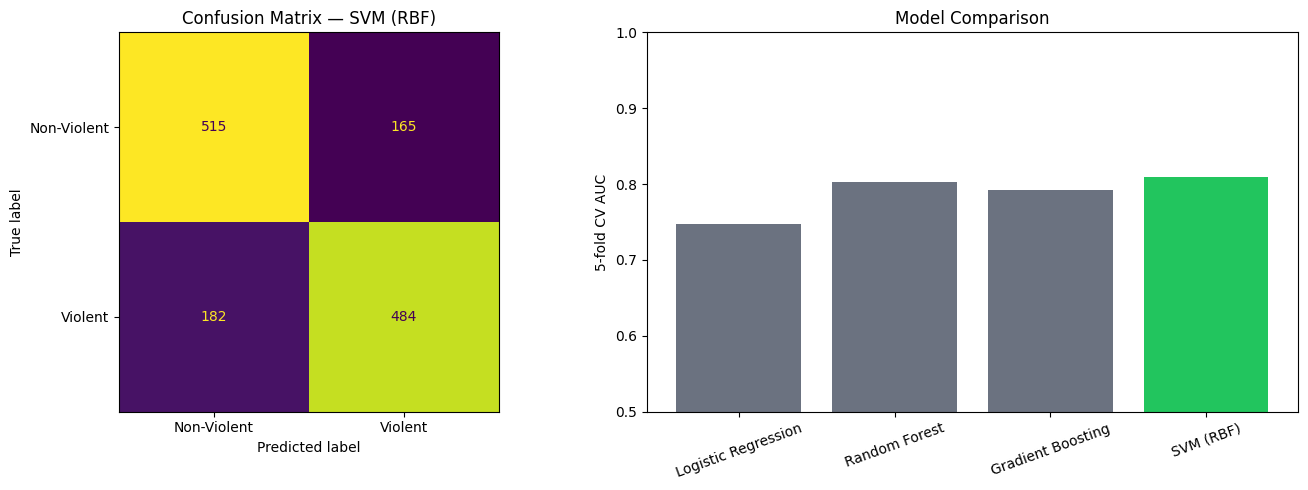

📈 Plot saved to Drive


In [12]:
# ── Classification report + confusion matrix ──────────────────────────────────
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Non-Violent', 'Violent']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Non-Violent', 'Violent'])
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title(f'Confusion Matrix — {best_name}')

names  = list(results.keys())
scores = [results[n]['cv'] for n in names]
colors = ['#22c55e' if n == best_name else '#6b7280' for n in names]
axes[1].bar(names, scores, color=colors)
axes[1].set_ylabel('5-fold CV AUC')
axes[1].set_title('Model Comparison')
axes[1].set_ylim(0.5, 1.0)
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(os.path.join(BASE, 'training_results_v2.png'), dpi=150)
plt.show()
print('📈 Plot saved to Drive')

In [14]:
# ── Step 2: Add pitch (F0) features → 43 features total ──────────────────────

def extract_features_v2(file_path, bits=BITS):
    y, sr = librosa.load(file_path, sr=SR)
    y_q   = adc_quantize(y, bits)
    feats = []

    # Original 41 features
    feats += [np.sum(y_q**2),
              np.mean(librosa.feature.zero_crossing_rate(y_q)),
              np.mean(librosa.feature.spectral_centroid(y=y_q, sr=sr))]

    mfcc  = librosa.feature.mfcc(y=y_q, sr=sr, n_mfcc=13)
    feats += list(np.mean(mfcc, axis=1))
    feats += list(np.std(mfcc,  axis=1))

    feats += [np.mean(librosa.feature.spectral_rolloff(y=y_q, sr=sr, roll_percent=0.85))]
    feats += [np.mean(librosa.feature.spectral_bandwidth(y=y_q, sr=sr))]
    feats += list(np.mean(librosa.feature.spectral_contrast(y=y_q, sr=sr), axis=1))

    rms    = librosa.feature.rms(y=y_q)
    feats += [np.mean(rms), np.std(rms)]

    tempo, _ = librosa.beat.beat_track(y=y_q, sr=sr)
    feats += [float(tempo)]

    # ── NEW: Pitch / F0 features (2) ──────────────────────────────────────────
    # F0 = fundamental frequency — rises with anger/fear, flat for neutral/calm
    # pyin is the most accurate pitch estimator in librosa
    f0, _, _ = librosa.pyin(y_q, fmin=50, fmax=400, sr=sr)
    f0_clean  = f0[~np.isnan(f0)]   # remove unvoiced frames
    feats += [
        np.mean(f0_clean) if len(f0_clean) > 0 else 0,   # average pitch
        np.std(f0_clean)  if len(f0_clean) > 0 else 0,   # pitch variability
    ]

    return np.array(feats)  # 43 features


# Re-extract with new features
print('Extracting train features (v2 — 43 features)...')
X_train_raw_v2, y_train_v2 = extract_split(train_data, 'Train v2')
print('Extracting test features (v2)...')
X_test_raw_v2,  y_test_v2  = extract_split(test_data,  'Test v2')
print(f'\n✅ Train: {X_train_raw_v2.shape}  Test: {X_test_raw_v2.shape}')

Extracting train features (v2 — 43 features)...


Train v2:   0%|          | 0/5282 [00:00<?, ?it/s]

/tmp/ipykernel_5764/2733750683.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  feats += [float(tempo)]


Extracting test features (v2)...


Test v2:   0%|          | 0/1346 [00:00<?, ?it/s]


✅ Train: (5282, 41)  Test: (1346, 41)


In [15]:
# Scale
from sklearn.preprocessing import RobustScaler

scaler_v2  = RobustScaler()
X_train_v2 = scaler_v2.fit_transform(X_train_raw_v2)
X_test_v2  = scaler_v2.transform(X_test_raw_v2)

# Retrain all models
results_v2 = {}
print('\n📊 Results v2 (43 features with pitch):')
print('-' * 68)
for name, m in models.items():
    m.fit(X_train_v2, y_train_v2)
    y_pred = m.predict(X_test_v2)
    y_prob = m.predict_proba(X_test_v2)[:, 1]
    acc  = accuracy_score(y_test_v2, y_pred)
    auc  = roc_auc_score(y_test_v2, y_prob)
    cv   = cross_val_score(m, X_train_v2, y_train_v2, cv=5, scoring='roc_auc')
    print(f'  {name:25s}  acc={acc:.3f}  auc={auc:.3f}  cv={cv.mean():.3f}±{cv.std():.3f}')
    results_v2[name] = {'model': m, 'acc': acc, 'auc': auc, 'cv': cv.mean()}

best_name_v2  = max(results_v2, key=lambda k: results_v2[k]['cv'])
best_model_v2 = results_v2[best_name_v2]['model']
print(f'\n🏆 Best v2: {best_name_v2}')

# Save if better than v1
best_v1 = max(results,    key=lambda k: results[k]['cv'])
best_v2 = max(results_v2, key=lambda k: results_v2[k]['cv'])

if results_v2[best_v2]['cv'] > results[best_v1]['cv']:
    joblib.dump(best_model_v2, os.path.join(BASE, 'violence_model.pkl'))
    joblib.dump(scaler_v2,     os.path.join(BASE, 'scaler.pkl'))
    print(f'✅ v2 is better — saved to Drive')
else:
    print(f'ℹ️ v1 was better — keeping original saved model')

print(f'\nv1 best cv: {results[best_v1]["cv"]:.3f}')
print(f'v2 best cv: {results_v2[best_v2]["cv"]:.3f}')


📊 Results v2 (43 features with pitch):
--------------------------------------------------------------------
  Logistic Regression        acc=0.713  auc=0.784  cv=0.748±0.036
  Random Forest              acc=0.704  auc=0.788  cv=0.803±0.011
  Gradient Boosting          acc=0.733  auc=0.806  cv=0.793±0.015
  SVM (RBF)                  acc=0.742  auc=0.816  cv=0.809±0.011

🏆 Best v2: SVM (RBF)
ℹ️ v1 was better — keeping original saved model

v1 best cv: 0.809
v2 best cv: 0.809


In [13]:
# ── Save model + scaler to Drive ──────────────────────────────────────────────
MODEL_PATH  = os.path.join(BASE, 'violence_model.pkl')
SCALER_PATH = os.path.join(BASE, 'scaler.pkl')

joblib.dump(best_model, MODEL_PATH)
joblib.dump(scaler,     SCALER_PATH)

print(f'✅ Saved to Google Drive:')
print(f'   {MODEL_PATH}')
print(f'   {SCALER_PATH}')
print()
print('Next steps:')
print('  1. Download both .pkl files from Drive')
print('  2. Replace the old ones in your Violence_detector folder')
print('  3. Run: streamlit run app.py')

✅ Saved to Google Drive:
   /content/drive/MyDrive/Violence_detector_v2/violence_model.pkl
   /content/drive/MyDrive/Violence_detector_v2/scaler.pkl

Next steps:
  1. Download both .pkl files from Drive
  2. Replace the old ones in your Violence_detector folder
  3. Run: streamlit run app.py


In [16]:
# ── Step 3: wav2vec2 fine-tuning ──────────────────────────────────────────────
!pip install -q transformers torch torchaudio datasets

using wav2vec2


In [17]:
import torch
import torchaudio
from transformers import (
    Wav2Vec2Processor,
    Wav2Vec2ForSequenceClassification,
    TrainingArguments,
    Trainer
)
from torch.utils.data import Dataset
import numpy as np

# Check if GPU is available — crucial for wav2vec2 training speed
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cpu':
    print('⚠️ No GPU detected — go to Runtime → Change runtime type → T4 GPU')
else:
    print('✅ GPU ready')

Using device: cuda
✅ GPU ready


In [18]:
# ── wav2vec2 Dataset ──────────────────────────────────────────────────────────
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")

class AudioDataset(Dataset):
    def __init__(self, data, processor, sr=16000, max_duration=4.0):
        self.data      = data
        self.processor = processor
        self.sr        = sr
        self.max_len   = int(sr * max_duration)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        path, label = self.data[idx]
        y, orig_sr  = torchaudio.load(path)

        # Resample if needed
        if orig_sr != self.sr:
            y = torchaudio.functional.resample(y, orig_sr, self.sr)

        # Mix to mono
        y = y.mean(dim=0).numpy()

        # Pad or trim to max_len
        if len(y) < self.max_len:
            y = np.pad(y, (0, self.max_len - len(y)))
        else:
            y = y[:self.max_len]

        inputs = self.processor(
            y,
            sampling_rate=self.sr,
            return_tensors="pt",
            padding=True
        )

        return {
            "input_values": inputs.input_values.squeeze(0),
            "labels":       torch.tensor(label, dtype=torch.long)
        }


train_dataset = AudioDataset(train_data, processor)
test_dataset  = AudioDataset(test_data,  processor)
print(f'✅ Train dataset: {len(train_dataset)} clips')
print(f'✅ Test dataset:  {len(test_dataset)} clips')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

✅ Train dataset: 5282 clips
✅ Test dataset:  1346 clips


In [20]:
model = Wav2Vec2ForSequenceClassification.from_pretrained(
    "facebook/wav2vec2-base",
    num_labels=2,
    classifier_proj_size=256,
    ignore_mismatched_sizes=True
)

# Freeze the feature extractor
for param in model.wav2vec2.feature_extractor.parameters():
    param.requires_grad = False

model = model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params:     {total_params:,}')
print(f'Trainable params: {trainable_params:,}')
print(f'Frozen params:    {total_params - trainable_params:,}')

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     | 
-----------------------------+------------+-
quantizer.weight_proj.weight | UNEXPECTED | 
quantizer.weight_proj.bias   | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
classifier.weight            | MISSING    | 
projector.bias               | MISSING    | 
projector.weight             | MISSING    | 
classifier.bias              | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total params:     94,569,090
Trainable params: 90,368,642
Frozen params:    4,200,448


In [22]:
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, roc_auc_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    probs = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    acc   = accuracy_score(labels, preds)
    auc   = roc_auc_score(labels, probs)
    return {"accuracy": acc, "auc": auc}

training_args = TrainingArguments(
    output_dir                  = "/content/wav2vec2_checkpoints",
    num_train_epochs            = 10,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 16,
    eval_strategy               = "epoch",   # renamed from evaluation_strategy
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "auc",
    learning_rate               = 1e-4,
    warmup_ratio                = 0.1,
    logging_steps               = 20,
    fp16                        = True,
    dataloader_num_workers      = 2,
    report_to                   = "none",
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = test_dataset,
    compute_metrics = compute_metrics,
)

print('🚀 Starting fine-tuning...')
trainer.train()
print('✅ Training complete')

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


🚀 Starting fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,Auc
1,0.492393,0.382985,0.841010,0.920565
2,0.424980,0.366511,0.847697,0.934506
3,0.381540,0.408721,0.857355,0.926476
4,0.419653,0.442669,0.828380,0.909496
5,0.195098,0.384262,0.855126,0.941745
6,0.172565,0.452743,0.881129,0.950087
7,0.122885,0.435919,0.896731,0.943715
8,0.059532,0.498115,0.884844,0.937338
9,0.034189,0.517241,0.897474,0.945703
10,0.020937,0.585010,0.893759,0.929051


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Training complete


FINAL RESULTS COMPARISON
Classical ML — SVM (41 features):          acc=0.742  auc=0.816
Classical ML — SVM (43 features + pitch):  acc=0.742  auc=0.816
wav2vec2 fine-tuned:                        acc=0.881  auc=0.950

              precision    recall  f1-score   support

 Non-Violent       0.85      0.93      0.89       680
     Violent       0.92      0.83      0.87       666

    accuracy                           0.88      1346
   macro avg       0.88      0.88      0.88      1346
weighted avg       0.88      0.88      0.88      1346



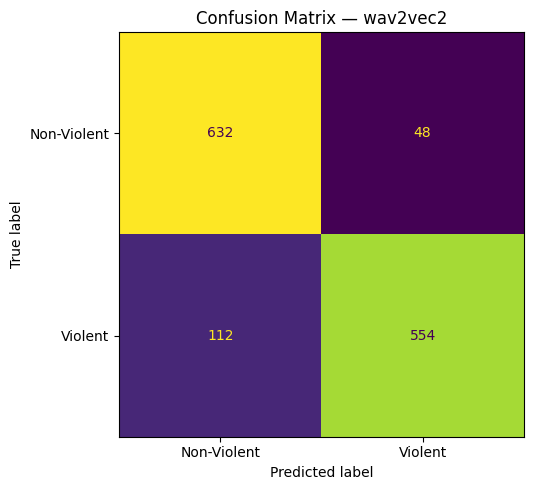

In [23]:
# ── Final evaluation ──────────────────────────────────────────────────────────
preds_output = trainer.predict(test_dataset)
logits       = preds_output.predictions
labels       = preds_output.label_ids

y_pred_w2v = np.argmax(logits, axis=1)
y_prob_w2v = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]

acc_w2v = accuracy_score(labels, y_pred_w2v)
auc_w2v = roc_auc_score(labels, y_prob_w2v)

print('=' * 60)
print('FINAL RESULTS COMPARISON')
print('=' * 60)
print(f'Classical ML — SVM (41 features):          acc={results[best_name]["acc"]:.3f}  auc={results[best_name]["auc"]:.3f}')
print(f'Classical ML — SVM (43 features + pitch):  acc={results_v2[best_name_v2]["acc"]:.3f}  auc={results_v2[best_name_v2]["auc"]:.3f}')
print(f'wav2vec2 fine-tuned:                        acc={acc_w2v:.3f}  auc={auc_w2v:.3f}')
print()
print(classification_report(labels, y_pred_w2v, target_names=['Non-Violent', 'Violent']))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm   = confusion_matrix(labels, y_pred_w2v)
disp = ConfusionMatrixDisplay(cm, display_labels=['Non-Violent', 'Violent'])
disp.plot(ax=ax, colorbar=False)
ax.set_title('Confusion Matrix — wav2vec2')
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'wav2vec2_results.png'), dpi=150)
plt.show()

In [24]:
# ── Save to Drive ─────────────────────────────────────────────────────────────
W2V_DIR = os.path.join(BASE, 'wav2vec2_model')
os.makedirs(W2V_DIR, exist_ok=True)

model.save_pretrained(W2V_DIR)
processor.save_pretrained(W2V_DIR)

print(f'✅ wav2vec2 model saved to: {W2V_DIR}')
print('   This folder contains the full model — use it in app.py for deployment')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ wav2vec2 model saved to: /content/drive/MyDrive/Violence_detector_v2/wav2vec2_model
   This folder contains the full model — use it in app.py for deployment
